In [5]:
import os
import glob
import time
import logging
from dask.diagnostics import ProgressBar
import xarray as xr              
import matplotlib.pyplot as plt  
import cartopy.crs as ccrs       
import pandas as pd             
import numpy as np
import matplotlib.font_manager as fm
from statsmodels.tsa.seasonal import seasonal_decompose  
import warnings
warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO,format="%(asctime)s | %(levelname)s | %(message)s",datefmt="%H:%M:%S")

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans'] 
plt.rcParams['font.family'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.unicode_minus'] = False 

=== 1.1 月度 Climatology  ===


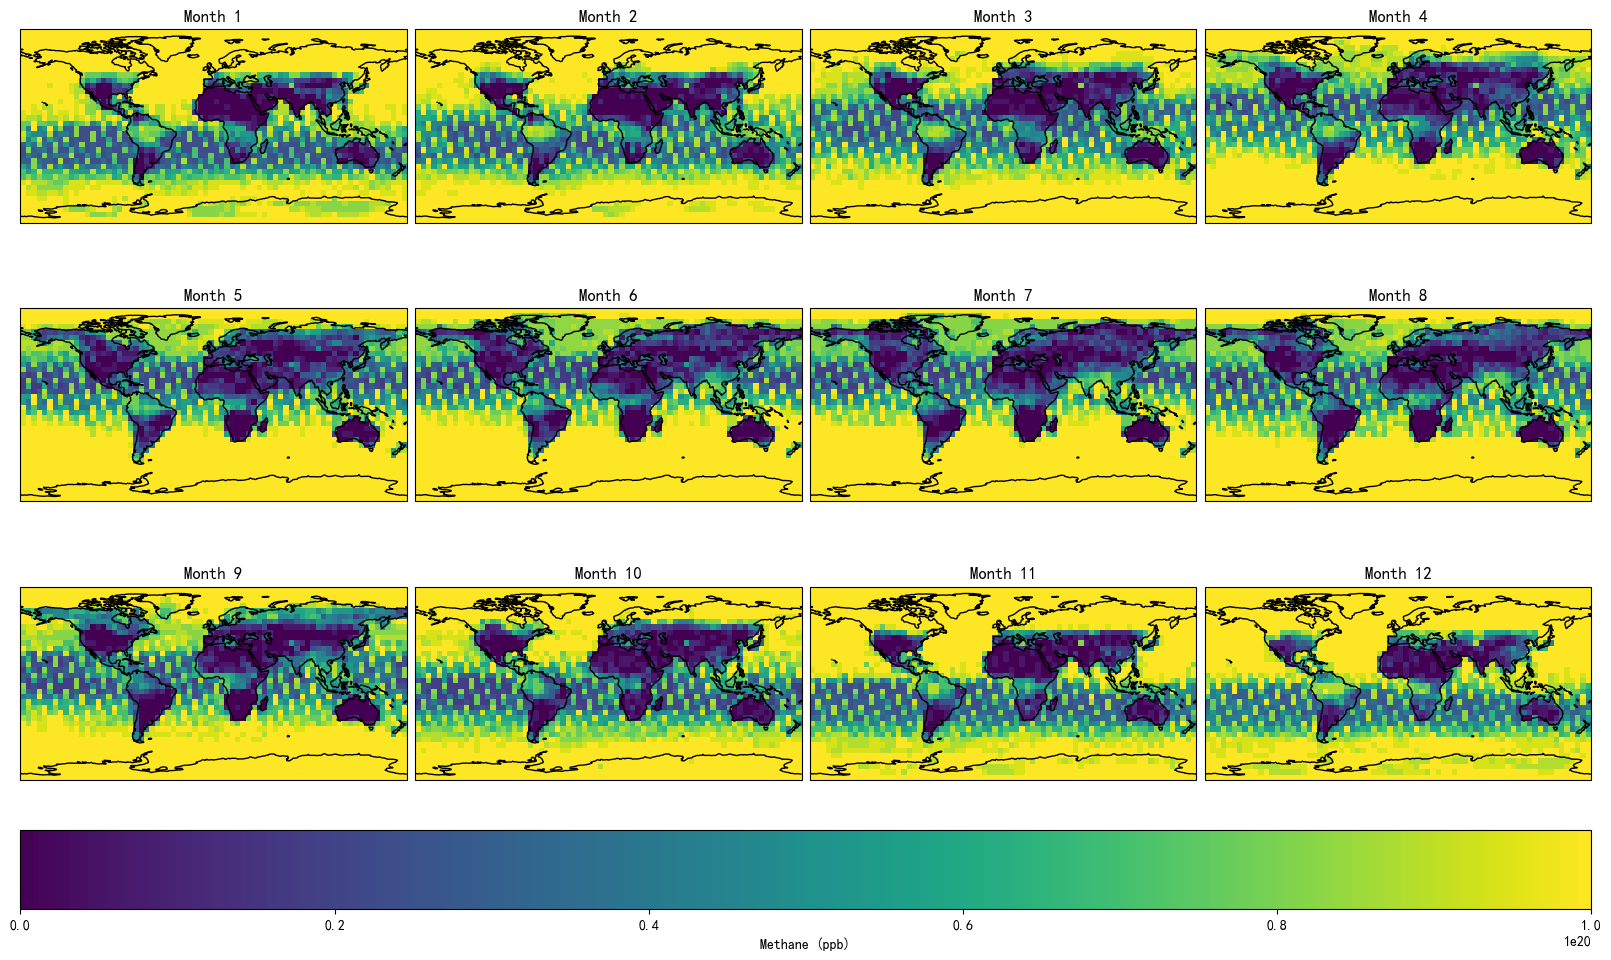

=== 1.2 全球平均甲烷浓度时间序列 ===


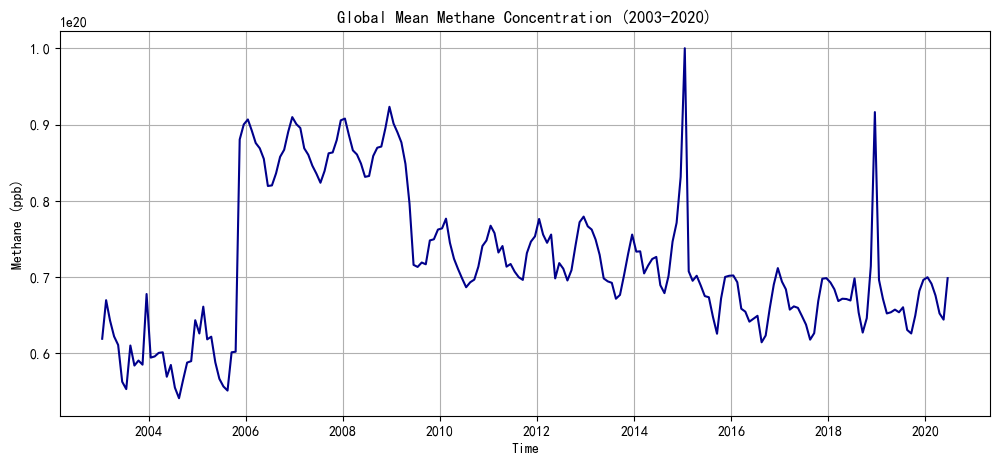

=== 1.3 去季节化甲烷浓度时间序列 [15°S, 150°W] ===


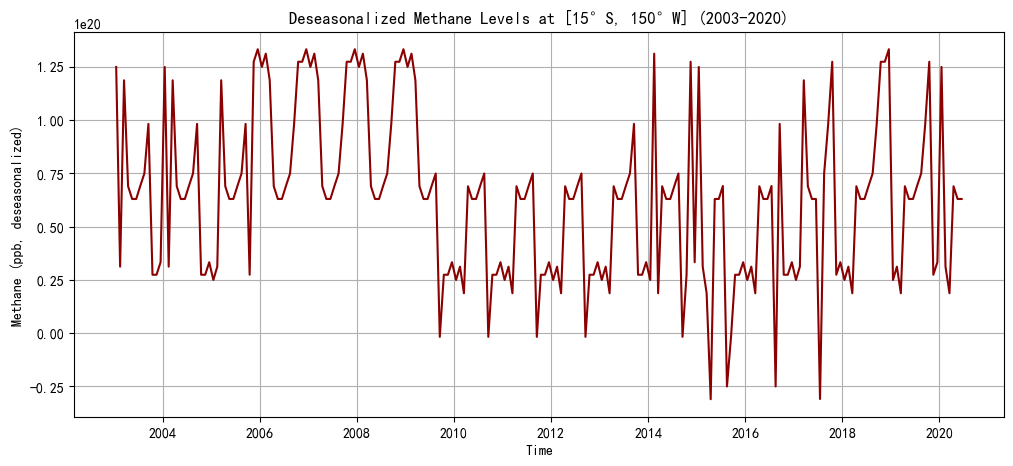

In [2]:
# 读取数据文件
ds = xr.open_dataset("200301_202006-C3S-L3_GHG-PRODUCTS-OBS4MIPS-MERGED-v4.3.nc") 
xch4 = ds['xch4'] 

# 1.1 月度 climatology 
print("=== 1.1 月度 Climatology  ===") 

# 按月份分组，计算多年平均 (climatology)
monthly_climatology = xch4.groupby('time.month').mean('time')

# 创建 12 个子图 ，使用 PlateCarree 投影，启用 constrained_layout 自动排版
fig, axes = plt.subplots(3, 4, figsize=(16, 10),subplot_kw={'projection': ccrs.PlateCarree()},constrained_layout=True)

# 遍历每个子图，绘制对应月份的 climatology
for i, ax in enumerate(axes.flat, start=1):
    data = monthly_climatology.sel(month=i)  # 选择第 i 月的 climatology 数据
    im = data.plot(ax=ax, transform=ccrs.PlateCarree(),  # 绘制地图
                   cmap='viridis', add_colorbar=False)   # 使用 viridis 色带
    ax.coastlines()                                     # 添加海岸线
    ax.set_title(f"Month {i}")                          # 设置子图标题为月份

# 添加统一的 colorbar，横向放置在底部
cbar = fig.colorbar(im, ax=axes.ravel().tolist(),orientation='horizontal', pad=0.05)
cbar.set_label("Methane (ppb)")  # 设置色标标签
plt.show()  # 显示图像

# 1.2 全球平均时间序列
print("=== 1.2 全球平均甲烷浓度时间序列 ===")

# 对纬度和经度维度取平均，得到全球平均浓度
global_mean = xch4.mean(dim=['lat', 'lon'])

# 绘制时间序列曲线
plt.figure(figsize=(12, 5))
global_mean.plot(color='darkblue')
plt.title("Global Mean Methane Concentration (2003-2020)")  # 设置标题
plt.xlabel("Time")                                          # 设置横轴标签
plt.ylabel("Methane (ppb)")                                 # 设置纵轴标签
plt.grid(True)                                              # 添加网格线
plt.show()                                                  # 显示图像

# 1.3 去季节化时间序列 
print("=== 1.3 去季节化甲烷浓度时间序列 [15°S, 150°W] ===")  

# 选取指定点位 [15°S, 150°W]，取最近的网格点
point_series = xch4.sel(lat=-15, lon=-150, method='nearest')

# 转换为 pandas Series，方便时间序列分析
ts = point_series.to_series()

# 使用 seasonal_decompose 分解时间序列 
decomposition = seasonal_decompose(ts, model='additive', period=12)

# 去季节化：原始序列 - 季节性成分
deseasonalized = ts - decomposition.seasonal

# 绘制去季节化后的时间序列
plt.figure(figsize=(12, 5))
plt.plot(deseasonalized.index, deseasonalized.values, color='darkred')
plt.title("Deseasonalized Methane Levels at [15°S, 150°W] (2003-2020)")  # 设置标题
plt.xlabel("Time")                                                       # 设置横轴标签
plt.ylabel("Methane (ppb, deseasonalized)")                              # 设置纵轴标签
plt.grid(True)                                                           # 添加网格线
plt.show()                                                               # 显示图像

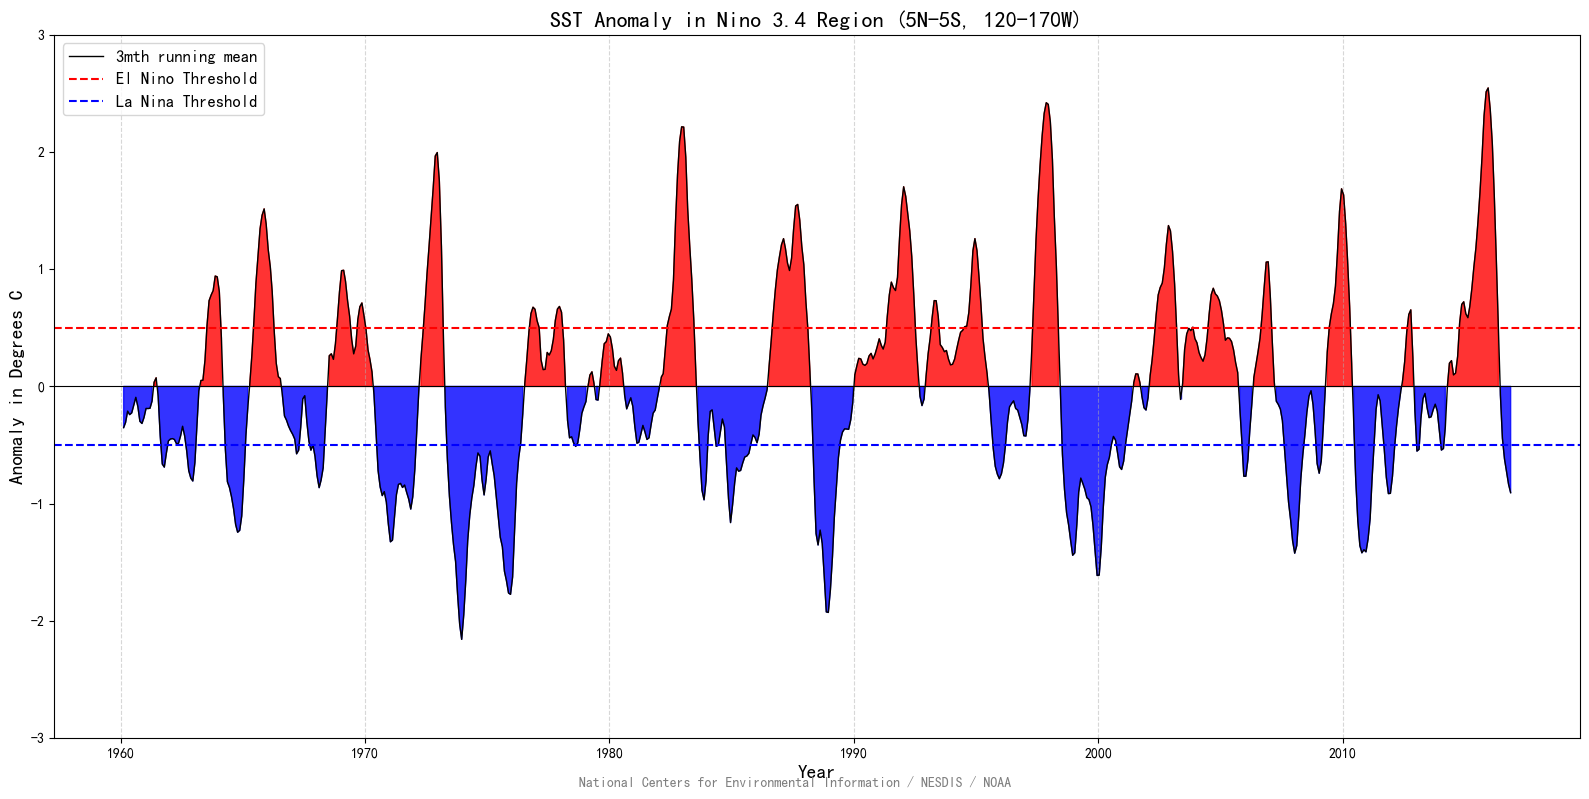

In [3]:
#2.1 计算气候态和异常值
#读取数据并提取 Niño 3.4 区域（5°S-5°N，190°E-240°E）
ds = xr.open_dataset("NOAA_NCDC_ERSST_v3b_SST.nc")
nino34_region = ds.sel(lat=slice(-5, 5), lon=slice(190, 240))

#计算区域平均SST
sst_region = nino34_region['sst'].mean(dim=['lat', 'lon'])   
sst_3m = sst_region.rolling(time=3, center=True).mean()      

#计算月气候态（长期平均）和异常值
climatology = sst_3m.groupby('time.month').mean('time')      # 每个月的长期平均（气候态）
anomalies = sst_3m.groupby('time.month') - climatology       # 异常值 = 实际值 - 气候态
ts = anomalies.to_series()                                   # 转换为 pandas Series

#2.2 绘制
#创建绘图窗口
fig, ax = plt.subplots(figsize=(16, 8))

# 绘制3个月滑动平均曲线
line_3m, = ax.plot(ts.index, ts.values, color='black', linewidth=1, label='3mth running mean')

# 填充 El Niño 区域
ax.fill_between(ts.index, 0, ts, where=(ts > 0), color='red', alpha=0.8)

# 填充 La Niña 区域
ax.fill_between(ts.index, 0, ts, where=(ts < 0), color='blue', alpha=0.8)

# 绘制 El Niño 阈值线
line_el = ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='El Nino Threshold')

# 绘制 La Niña 阈值线
line_la = ax.axhline(-0.5, color='blue', linestyle='--', linewidth=1.5, label='La Nina Threshold')

# 绘制零线
ax.axhline(0, color='black', linewidth=0.8)

# 设置纵轴范围和网格
ax.set_ylim(-3, 3)                          
ax.grid(axis='x', linestyle='--', alpha=0.5) 
ax.grid(axis='y', visible=False)             

# 设置标题和坐标轴标签
ax.set_title("SST Anomaly in Nino 3.4 Region (5N-5S, 120-170W)", fontsize=16)
ax.set_ylabel("Anomaly in Degrees C", fontsize=14)
ax.set_xlabel("Year", fontsize=14)

# 图例自动选择最佳位置
ax.legend(handles=[line_3m, line_el, line_la], fontsize=12, loc='best')

# 底部机构标注
plt.figtext(0.5, 0.01, "National Centers for Environmental Information / NESDIS / NOAA", ha='center', fontsize=10, color='gray')

# 自动调整布局，避免元素重叠
plt.tight_layout()
plt.show()

正在读取数据...
SPWATR维度信息： ('time', 'lat', 'lon')
SPWATR单位： kg m-2 s-1
开始计算...
步骤1: 计算区域平均...
步骤2: 月度重采样...
步骤3: 计算气候态和异常值（去除月季节循环）...
计算完成！
大数据集，触发并行计算...


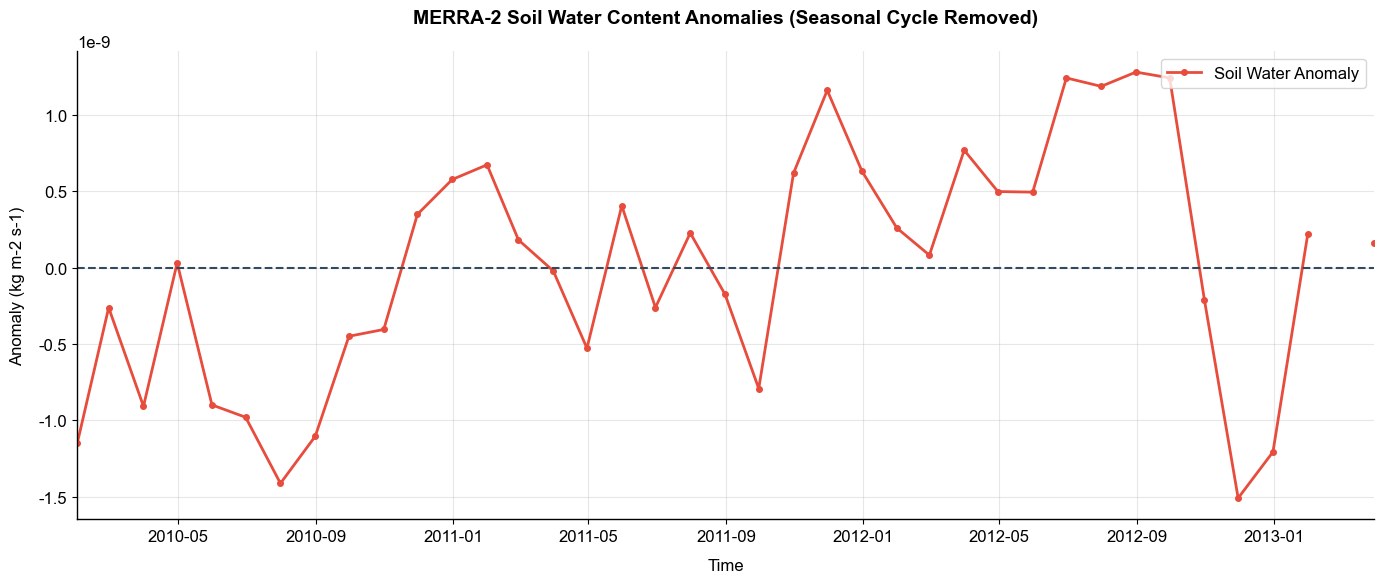

In [4]:
# 3.1数据读取

print("正在读取数据...")  

# 使用分块和并行读取
ds = xr.open_mfdataset("*.nc4", concat_dim="time", combine="nested", parallel=True, chunks={'time': 100, 'lat': 50, 'lon': 50}, preprocess=None)

#变量选择与预处理
print("SPWATR维度信息：", ds['SPWATR'].dims) 
print("SPWATR单位：", ds['SPWATR'].attrs.get('units', '未知')) 
var = ds['SPWATR']  # 提取土壤水分变量 SPWATR

# 去除月季节循环
print("开始计算...") 
print("步骤1: 计算区域平均...")
ts_spatial_mean = var.mean(dim=['lat', 'lon'], skipna=True) 
print("步骤2: 月度重采样...")
ts_monthly = ts_spatial_mean.resample(time='1ME').mean(skipna=True) 
print("步骤3: 计算气候态和异常值（去除月季节循环）...")
# 计算月季节循环
climatology = ts_monthly.groupby('time.month').mean(dim='time') 
# 去除月季节循环
anomalies = ts_monthly.groupby('time.month') - climatology 
ts = anomalies  # 使用去除季节循环后的异常值作为最终时间序列
print("计算完成！") 

# 实际计算并释放内存
# 使用compute()实际计算
if len(ds.time) > 1000:  
    print("大数据集，触发并行计算...")
    ts_values = ts.compute()  
else:
    ts_values = ts  

# 关闭数据集，释放内存资源
ds.close()  

# 去除季节循环的异常值
plt.rcParams.update({'font.size': 12, 'font.family': 'Arial', 'axes.linewidth': 1.0})
fig, ax = plt.subplots(figsize=(14, 6))  

time_data = ts_values['time']   # 提取时间数据
values_data = ts_values.values  # 提取异常值数据

time_min = time_data.min()  # 数据起始时间
time_max = time_data.max()  # 数据结束时间

if len(time_data) > 100:  
    ax.plot(time_data, values_data, color='#E74C3C', linewidth=1.5, label='Soil Water Anomaly')  
    ax.plot(time_data[::12], values_data[::12], 'o', color='#E74C3C', markersize=3, alpha=0.7)
else:
    ax.plot(time_data, values_data, color='#E74C3C', linewidth=2.0, marker='o', markersize=4, label='Soil Water Anomaly') 
ax.axhline(y=0, color='#34495E', linewidth=1.5, linestyle='--') 

ax.set_xlim(time_min, time_max)
ax.set_title('MERRA-2 Soil Water Content Anomalies (Seasonal Cycle Removed)', pad=20, fontsize=14, fontweight='bold') 
ax.set_ylabel(f'Anomaly ({ds["SPWATR"].attrs.get("units", "m³/m³")})', labelpad=10) 
ax.set_xlabel('Time', labelpad=10) 
ax.legend(loc='upper right', frameon=True, shadow=False) 
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8) 
ax.spines['top'].set_visible(False)  
ax.spines['right'].set_visible(False) 
plt.tight_layout()  
plt.show()

12:54:38 | INFO | Step 1: Find input files (*.nc4)
12:54:38 | INFO | Found 1102 files
12:54:38 | INFO | File search completed: 0.01 seconds
12:54:38 | INFO | Open multi-file dataset (xarray + dask)
12:56:35 | INFO | Dataset opened: 117.01 seconds
12:56:35 | INFO | Select variable: SPWATR
12:56:35 | INFO | Calculate spatial average (lat/lon) (lazy computation)
12:56:36 | INFO | Spatial average completed: 0.24 seconds
12:56:36 | INFO | Resample to monthly average (1ME) (lazy computation)
12:56:36 | INFO | Monthly average completed: 0.38 seconds
12:56:36 | INFO | Build monthly climatology and anomalies (lazy computation)
12:56:36 | INFO | Climatology/anomalies completed: 0.10 seconds
12:56:36 | INFO | Compute monthly data and anomalies (with progress bar)


[########################################] | 100% Completed | 20m 5ss
[########################################] | 100% Completed | 18m 24s


13:35:37 | INFO | Data computation completed: 2340.79 seconds
13:35:37 | INFO | Calculate spatial anomalies for global distribution map
13:35:38 | INFO | Spatial anomalies calculation completed: 1.46 seconds
13:35:38 | INFO | Plot 1/5: Global soil moisture raw time series


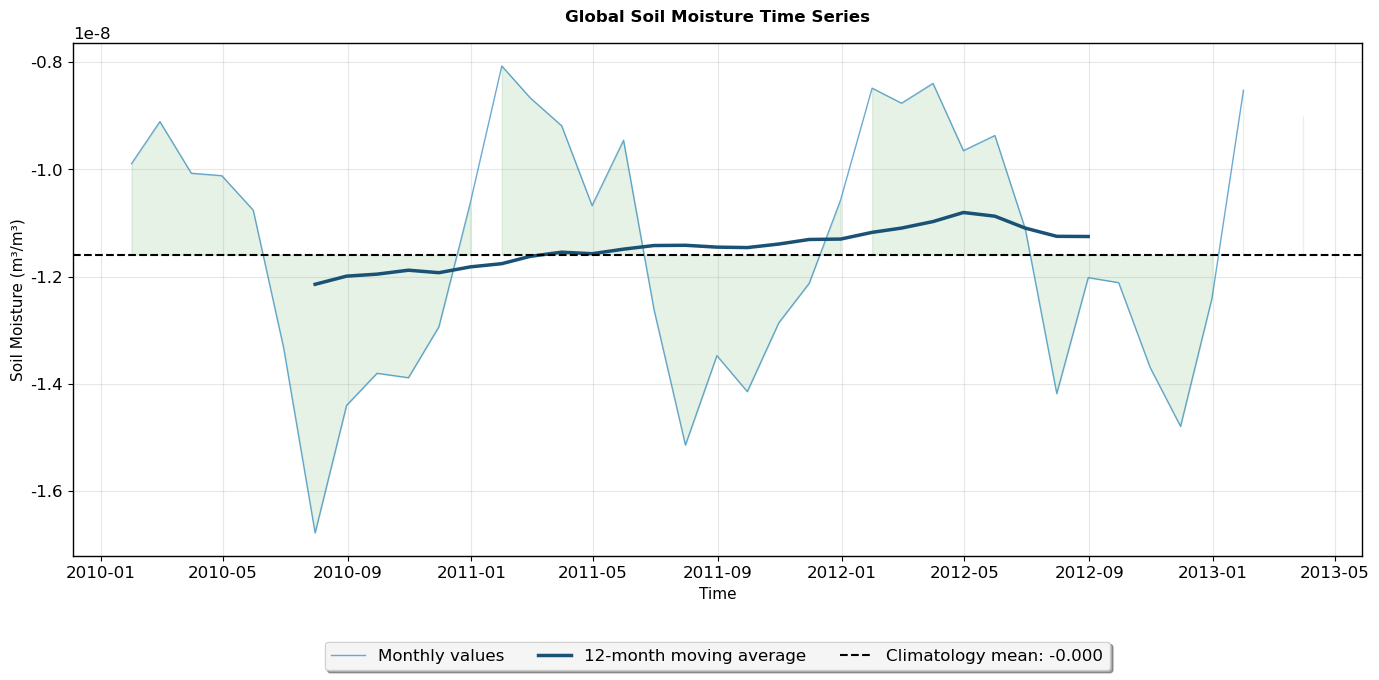

13:46:18 | INFO | Plot 1 completed: 639.92 seconds
13:46:18 | INFO | Plot 2/5: Monthly climatology cycle


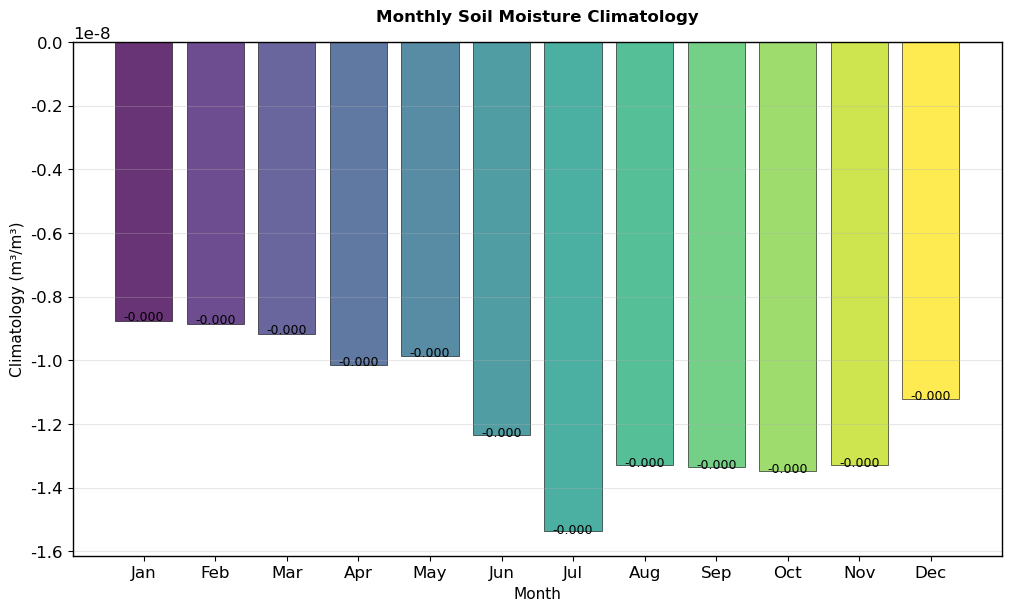

13:59:17 | INFO | Plot 2 completed: 779.09 seconds
13:59:17 | INFO | Plot 3/5: Global soil moisture anomaly distribution


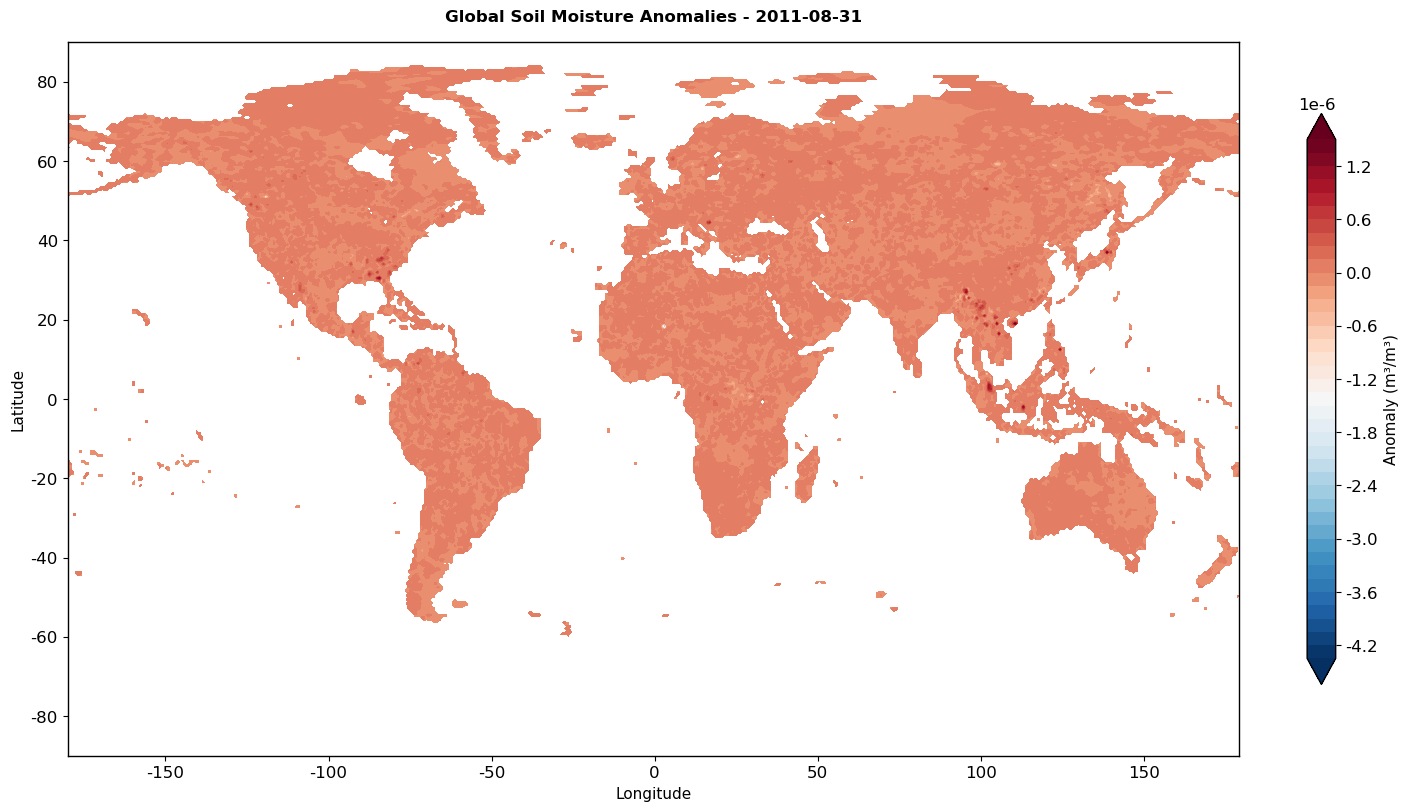

14:00:22 | INFO | Plot 3 completed: 64.14 seconds
14:00:22 | INFO | Plot 4/5: Seasonal variation analysis


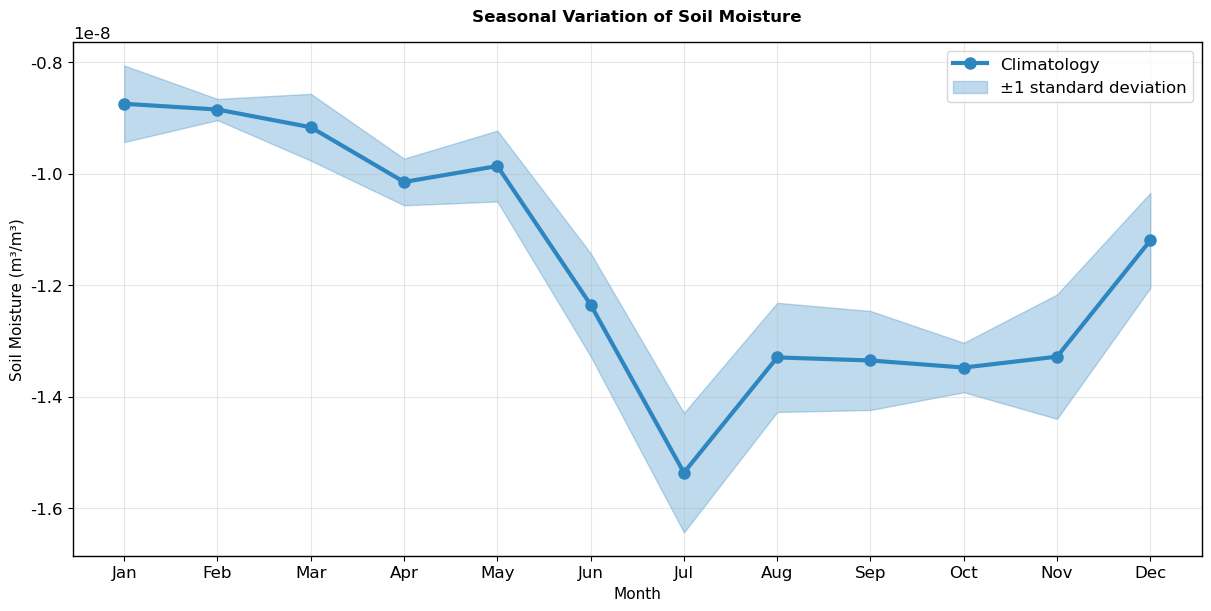

14:28:31 | INFO | Plot 4 completed: 1689.74 seconds
14:28:31 | INFO | Plot 5/5: Anomaly time series


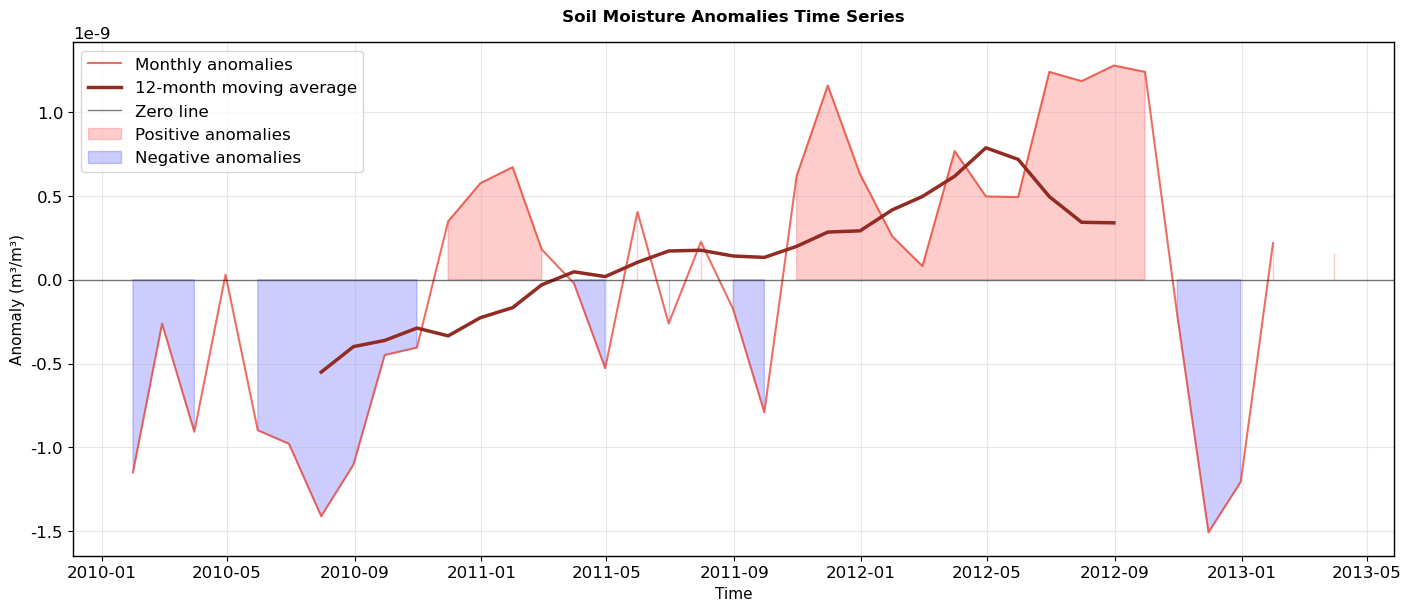

14:28:32 | INFO | Plot 5 completed: 0.30 seconds
14:28:32 | INFO | Close dataset
14:28:37 | INFO | Dataset closed: 5.64 seconds
14:28:37 | INFO | All steps completed successfully!


In [6]:
#3.2
def stage(msg):  # 定义阶段性日志函数
    logging.info(msg)  # 输出阶段性提示信息

def start_timer():  # 启动计时器函数
    return time.perf_counter()  # 返回高精度计时起点

def end_timer(t0, label="Time elapsed"):  # 结束计时器并记录耗时
    logging.info(f"{label}: {time.perf_counter() - t0:.2f} seconds")  # 输出耗时，保留两位小数

# 数据读取
stage("Step 1: Find input files (*.nc4)")  # 日志：开始查找输入nc4文件
t0 = start_timer()  # 开始计时：文件搜索
files = sorted(glob.glob("*.nc4"))  # 在当前目录查找所有nc4文件并排序
if not files:  # 如果未找到任何文件
    raise FileNotFoundError("No .nc4 files found in current directory")  # 抛出异常并提示
logging.info(f"Found {len(files)} files")  # 记录找到的文件数量
end_timer(t0, "File search completed")  # 结束计时：文件搜索完成

stage("Open multi-file dataset (xarray + dask)")  # 日志：开始打开多文件数据集
t0 = start_timer()  # 开始计时：打开数据集
ds = xr.open_mfdataset(  # 采用xarray+dask懒加载打开多文件
    files,  # 输入文件列表
    concat_dim="time",  # 沿time维度拼接
    combine="nested",  # 使用嵌套组合方式
    parallel=True,  # 启用并行读取
    chunks={'time': 100, 'lat': 50, 'lon': 50}  # 设置dask分块大小以平衡内存与并行
)  # 结束open_mfdataset参数
end_timer(t0, "Dataset opened")  # 结束计时：数据集打开完成

stage("Select variable: SPWATR")  # 日志：选择变量SPWATR
var = ds['SPWATR']  # 提取数据集中名为SPWATR的变量（例如土壤含水量）

#  区域平均 + 月度数据
stage("Calculate spatial average (lat/lon) (lazy computation)")  # 日志：计算空间（纬度经度）平均
t0 = start_timer()  # 开始计时：空间平均
ts_spatial_mean = var.mean(dim=['lat','lon'], skipna=True)  # 对lat和lon维度求平均，忽略NaN
end_timer(t0, "Spatial average completed")  # 结束计时：空间平均完成

stage("Resample to monthly average (1ME) (lazy computation)")  # 日志：重采样为月平均
t0 = start_timer()  # 开始计时：月平均
ts_monthly = ts_spatial_mean.resample(time='1ME').mean(skipna=True)  # 以月末为标签进行月平均重采样
end_timer(t0, "Monthly average completed")  # 结束计时：月平均完成

stage("Build monthly climatology and anomalies (lazy computation)")  # 日志：构建月气候态与距平
t0 = start_timer()  # 开始计时：气候态与距平
climatology = ts_monthly.groupby('time.month').mean(dim='time')  # 按月份分组，对所有年求平均得到月气候态
anomalies = ts_monthly.groupby('time.month') - climatology  # 月份分组后减去对应气候态得到月距平
end_timer(t0, "Climatology/anomalies completed")  # 结束计时：气候态与距平完成

stage("Compute monthly data and anomalies (with progress bar)")  # 日志：计算月度数据与距平（带进度条）
t0 = start_timer()  # 开始计时：计算
with ProgressBar():  # 显示dask计算进度条
    ts_monthly_computed = ts_monthly.compute()  # 触发计算并得到月平均时间序列
    ts_anomalies_computed = anomalies.compute()  # 触发计算并得到距平时间序列
end_timer(t0, "Data computation completed")  # 结束计时：数据计算完成

# 计算空间异常值
stage("Calculate spatial anomalies for global distribution map")  # 日志：计算空间距平用于分布图
t0 = start_timer()  # 开始计时：空间距平
var_monthly = var.resample(time='1ME').mean(skipna=True)  # 对原始变量按月重采样得到月平均场
climatology_map = var_monthly.groupby('time.month').mean(dim='time')  # 空间上的月气候态（每月对多年平均）
anomalies_map = var_monthly.groupby('time.month') - climatology_map  # 空间上的月距平（逐月减去气候态）

sample_time_idx = len(anomalies_map.time) // 2  # 选择中间位置的时间索引用于示例绘图
sample_time = anomalies_map.time[sample_time_idx].values  # 获取该时间点的具体时间值（numpy datetime）
spatial_anomaly = anomalies_map.isel(time=sample_time_idx)  # 取该时间点的空间距平场
end_timer(t0, "Spatial anomalies calculation completed")  # 结束计时：空间距平计算完成

# 绘图样式设置
plt.rcParams.update({'font.size': 12, 'font.family': 'DejaVu Sans', 'figure.constrained_layout.use': True, 'figure.titlesize': 14, 'axes.titlesize': 12, 'axes.labelsize': 11}) 

# (1) 时间序列图：全球平均原始值
stage("Plot 1/5: Global soil moisture raw time series")  # 日志：绘制图1—全球平均原始时间序列
t0 = start_timer()  # 开始计时：图1
fig, ax = plt.subplots(figsize=(14, 7))  # 创建图与坐标轴，设定尺寸

ts_original = ts_monthly_computed  # 使用已计算的月平均时间序列作为原始序列
window_size = 12  # 定义滚动窗口大小为12个月（年尺度平滑）
smoothed = ts_original.rolling(time=window_size, center=True).mean()  # 居中滚动计算移动平均

ax.plot(ts_original['time'].values, ts_original.values,  # 绘制月平均原始值曲线
        color='#2E86C1', linewidth=1, alpha=0.7, label='Monthly values')  # 设置颜色、线宽、透明度与图例标签
ax.plot(smoothed['time'].values, smoothed.values,  # 绘制12月移动平均曲线
        color='#1A5276', linewidth=2.5, label=f'{window_size}-month moving average')  # 设置样式与图例

climatology_mean = climatology.mean().values  # 计算月气候态的整体平均（参考线）
ax.axhline(y=climatology_mean, color='black', linestyle='--',  # 添加气候态平均的水平虚线
           linewidth=1.5, label=f'Climatology mean: {climatology_mean:.3f}')  # 设置样式与标签

current_year = ts_original['time'].dt.year.min().values  # 取得时间序列中的最小年份
max_year = ts_original['time'].dt.year.max().values  # 取得时间序列中的最大年份

while current_year <= max_year:  # 遍历每一个年份
    year_data = ts_original.sel(time=ts_original['time'].dt.year == current_year)  # 选取该年的数据
    if len(year_data) > 0:  # 如果该年有数据
        ax.fill_between(year_data['time'].values, year_data.values, climatology_mean,  # 在该年曲线与均值之间填充色块
                       alpha=0.1, color='green')  # 轻微填充以强调偏离均值区域
    current_year += 1  # 年份递增

ax.set_title("Global Soil Moisture Time Series", fontweight='bold', pad=15)  # 设置图标题、加粗与上方间距
ax.set_ylabel("Soil Moisture (m³/m³)")  # 设置y轴标签
ax.set_xlabel("Time")  # 设置x轴标签

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),  # 将图例置于图下方居中
          ncol=3, framealpha=0.9, fancybox=True, shadow=True)  # 设置图例列数、透明度、圆角与阴影
ax.grid(True, alpha=0.3)  # 添加网格线，轻度透明

plt.tight_layout()  # 紧凑布局防止元素重叠
plt.show()  # 显示图1
end_timer(t0, "Plot 1 completed")  # 结束计时：图1完成

# (2) 月气候态图
stage("Plot 2/5: Monthly climatology cycle")  # 日志：绘制图2—月气候态循环
t0 = start_timer()  # 开始计时：图2
fig, ax = plt.subplots(figsize=(10, 6))  # 创建图与坐标轴，设定尺寸

months = range(1, 13)  # 定义月份数值1-12
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',  # 定义月份名称
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']  # 完成月份名称列表

bars = ax.bar(months, climatology.values, color=plt.cm.viridis(np.linspace(0, 1, 12)),  # 绘制柱状图，使用Viridis渐变色
              alpha=0.8, edgecolor='black', linewidth=0.5)  # 设置透明度、边框颜色与线宽

for bar, value in zip(bars, climatology.values):  # 遍历柱子与对应数值
    height = bar.get_height()  # 获取柱子高度
    ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,  # 在柱子顶部稍上方标注数值
            f'{value:.3f}', ha='center', va='bottom', fontsize=9)  # 居中对齐，设置字体大小

ax.set_xticks(months)  # 设置x轴刻度为1-12
ax.set_xticklabels(month_names)  # 设置x轴刻度标签为月份名称
ax.set_xlabel("Month")  # 设置x轴标签
ax.set_ylabel("Climatology (m³/m³)")  # 设置y轴标签
ax.set_title("Monthly Soil Moisture Climatology", fontweight='bold', pad=15)  # 设置标题与间距
ax.grid(True, alpha=0.3, axis='y')  # 添加仅y方向的网格线
plt.show()  # 显示图2
end_timer(t0, "Plot 2 completed")  # 结束计时：图2完成

# (3) 空间分布图
stage("Plot 3/5: Global soil moisture anomaly distribution")  # 日志：绘制图3—全球距平空间分布
t0 = start_timer()  # 开始计时：图3
fig, ax = plt.subplots(figsize=(14, 8))  # 创建图与坐标轴，设定尺寸

lon = spatial_anomaly.lon.values  # 取经度数组
lat = spatial_anomaly.lat.values  # 取纬度数组
data = spatial_anomaly.values  # 取空间距平数据数组

lon_grid, lat_grid = np.meshgrid(lon, lat)  # 生成网格用于等值线填色绘图

contour = ax.contourf(lon_grid, lat_grid, data,  # 绘制填色等值线图
                     levels=50,  # 设置等值线层级数量
                     cmap='RdBu_r',  # 使用红蓝反转色图表示正负距平
                     extend='both')  # 色带两端延伸以表示超出范围的值

cbar = plt.colorbar(contour, ax=ax, shrink=0.8)  # 添加颜色条并缩放
cbar.set_label('Anomaly (m³/m³)')  # 设置颜色条标签

ax.set_title(f"Global Soil Moisture Anomalies - {np.datetime_as_string(sample_time, unit='D')}",  # 设置标题包含日期
             fontweight='bold', pad=15)  # 加粗并增加上方间距
ax.set_xlabel("Longitude")  # 设置x轴标签为经度
ax.set_ylabel("Latitude")  # 设置y轴标签为纬度

plt.show()  # 显示图3
end_timer(t0, "Plot 3 completed")  # 结束计时：图3完成

# (4) 季节变化图
stage("Plot 4/5: Seasonal variation analysis")  # 日志：绘制图4—季节变化分析
t0 = start_timer()  # 开始计时：图4
fig, ax = plt.subplots(figsize=(12, 6))  # 创建图与坐标轴，设定尺寸

monthly_std = ts_monthly_computed.groupby('time.month').std(dim='time')  # 计算每月的跨年标准差，表示季节性波动

months = range(1, 13)  # 定义月份1-12
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',  # 定义月份名称
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']  # 完成月份名称列表

ax.plot(months, climatology.values, 'o-', color='#2E86C1',  # 绘制月气候态曲线，圆点+折线
        linewidth=3, markersize=8, label='Climatology')  # 设置线宽、标记大小与图例

ax.fill_between(months,  # 绘制±1标准差阴影带
               climatology.values - monthly_std.values,  # 下界：气候态-标准差
               climatology.values + monthly_std.values,  # 上界：气候态+标准差
               alpha=0.3, color='#2E86C1', label='±1 standard deviation')  # 设置透明度、颜色与图例

ax.set_xticks(months)  # 设置x轴刻度为1-12
ax.set_xticklabels(month_names)  # 设置x轴刻度标签为月份名称
ax.set_xlabel("Month")  # 设置x轴标签
ax.set_ylabel("Soil Moisture (m³/m³)")  # 设置y轴标签
ax.set_title("Seasonal Variation of Soil Moisture", fontweight='bold', pad=15)  # 设置标题与间距
ax.legend()  # 显示图例
ax.grid(True, alpha=0.3)  # 添加网格线
plt.show()  # 显示图4
end_timer(t0, "Plot 4 completed")  # 结束计时：图4完成

# (5) 异常值时间序列
stage("Plot 5/5: Anomaly time series")  # 日志：绘制图5—距平时间序列
t0 = start_timer()  # 开始计时：图5
fig, ax = plt.subplots(figsize=(14, 6))  # 创建图与坐标轴，设定尺寸

ax.plot(ts_anomalies_computed['time'].values, ts_anomalies_computed.values,  # 绘制月度距平曲线
        color='#E74C3C', linewidth=1.5, alpha=0.8, label='Monthly anomalies')  # 设置样式与图例

window_size = 12  # 定义滚动窗口大小为12个月
smoothed_anomalies = ts_anomalies_computed.rolling(time=window_size, center=True).mean()  # 计算居中的12月移动平均
ax.plot(smoothed_anomalies['time'].values, smoothed_anomalies.values,  # 绘制距平的移动平均曲线
        color='#922B21', linewidth=2.5, label=f'{window_size}-month moving average')  # 设置样式与图例

ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='Zero line')  # 添加零线作为参考

ax.fill_between(ts_anomalies_computed['time'].values,  # 对正距平区域进行红色填充
               ts_anomalies_computed.values, 0,  # 从距平值到零线
               where=ts_anomalies_computed.values >= 0,  # 条件：非负
               color='red', alpha=0.2, label='Positive anomalies')  # 设置颜色与透明度
ax.fill_between(ts_anomalies_computed['time'].values,  # 对负距平区域进行蓝色填充
               ts_anomalies_computed.values, 0,  # 从距平值到零线
               where=ts_anomalies_computed.values < 0,  # 条件：负
               color='blue', alpha=0.2, label='Negative anomalies')  # 设置颜色与透明度

ax.set_title("Soil Moisture Anomalies Time Series", fontweight='bold', pad=15)  # 设置图标题与间距
ax.set_ylabel("Anomaly (m³/m³)")  # 设置y轴标签
ax.set_xlabel("Time")  # 设置x轴标签
ax.legend(loc='best')  # 自动选择最佳图例位置
ax.grid(True, alpha=0.3)  # 添加网格线
plt.show()  # 显示图5
end_timer(t0, "Plot 5 completed")  # 结束计时：图5完成

# 关闭数据集
stage("Close dataset")  # 日志：关闭数据集
t0 = start_timer()  # 开始计时：关闭数据集
ds.close()  # 关闭xarray数据集，释放资源
end_timer(t0, "Dataset closed")  # 结束计时：数据集关闭完成

stage("All steps completed successfully!")  # 日志：所有步骤成功完成